<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sourit/Untrusted_Client_Networks(FL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Untrusted Client Networks & Data Poisoning
## Securing Aggregation against Byzantine Attacks

**Objective:**
Standard Federated Averaging (FedAvg) assumes all participating clients are honest. If malicious clients infiltrate the network, they can execute a Data Poisoning attack (such as Label Flipping) to intentionally corrupt the global model's decision boundary.

This notebook tests the vulnerability of the network against a 20% compromise rate, and evaluates five distinct aggregation methodologies to determine which defense, if any, can survive targeted data poisoning.

**Methodology:**
* **Dataset:** CIFAR-10 (Distributed IID).
* **Adversarial Setup:** Out of 10 clients, 2 are malicious. During their local training loop, their labels are systematically scrambled (Label Flipping: `(label + 5) % 10`).
* **Defense Strategies Tested:**
  1. **FedAvg:** The vulnerable baseline.
  2. **Trimmed Mean:** Sorts updates and discards the extreme outliers (top/bottom 10%) before averaging.
  3. **Gradient Clipping (Absolute):** Limits the overall magnitude of the model's absolute weights to prevent explosive updates.
  4. **FedProx:** Adds a proximal penalty to anchor clients to the global model, theoretically slowing down the hackers.
  5. **SCAFFOLD:** Uses control variates to correct gradient drift across the network.

### Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import copy
import matplotlib.pyplot as plt
import math
import pandas as pd

### Architecture

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# 1. Lightweight CNN for CIFAR-10 (Faster Iteration)
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

### Data Prepararion

In [4]:
NUM_CLIENTS = 10
MALICIOUS_CLIENTS = [8,9]# The last two clients are hackers

In [5]:
transform = transforms.Compose([transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

cifar_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

split_size = len(cifar_full) // NUM_CLIENTS
cifar_split = random_split(cifar_full, [split_size] * NUM_CLIENTS)

client_loaders = [DataLoader(ds, batch_size=64, shuffle=True) for ds in cifar_split]
test_loader = DataLoader(cifar_test, batch_size=1000, shuffle=False)

print(f"Prepared CIFAR-10: 10 Clients. Clients {MALICIOUS_CLIENTS} are malicious.")

100%|██████████| 170M/170M [00:02<00:00, 73.8MB/s]


Prepared CIFAR-10: 10 Clients. Clients [8, 9] are malicious.


### Functions

In [6]:
def standard_fedavg(client_weights_list):
    avg_weights = copy.deepcopy(client_weights_list[0])
    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in client_weights_list])
        avg_weights[key] = torch.mean(stacked_weights, dim=0)
    return avg_weights

In [7]:
def trimmed_mean_aggregation(client_weights_list, trim_ratio=0.1):
    avg_weights = copy.deepcopy(client_weights_list[0])
    num_clients = len(client_weights_list)
    trim_count = int(num_clients * trim_ratio)
    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in client_weights_list])
        sorted_weights, _ = torch.sort(stacked_weights, dim=0)
        trimmed_weights = sorted_weights[trim_count : num_clients - trim_count]
        avg_weights[key] = torch.mean(trimmed_weights, dim=0)
    return avg_weights

In [8]:
def absolute_weight_clipping_aggregation(client_weights_list, clip_threshold=2.0):
    """
    Calculates the L2 norm of the ENTIRE client weight vector (absolute position)
    and scales the whole model down if it exceeds the threshold.
    """
    clipped_weights_list = []

    # 1. Calculate and clip each client's absolute weights
    for client_weights in client_weights_list:
        squared_sum = 0.0

        # Calculate the L2 Norm (magnitude) of the ENTIRE model
        for key in client_weights.keys():
            squared_sum += torch.sum(client_weights[key] ** 2).item()

        l2_norm = math.sqrt(squared_sum)

        # Calculate the scaling factor (if norm > threshold, scale > 1)
        scale = max(1.0, l2_norm / clip_threshold)

        # Apply the scale down to the absolute weights
        clipped_client_weights = {}
        for key in client_weights.keys():
            clipped_client_weights[key] = client_weights[key] / scale

        clipped_weights_list.append(clipped_client_weights)

    # 2. Average the safely clipped absolute weights
    avg_weights = copy.deepcopy(clipped_weights_list[0])

    for key in avg_weights.keys():
        stacked_weights = torch.stack([client[key] for client in clipped_weights_list])
        avg_weights[key] = torch.mean(stacked_weights, dim=0)

    # Note: We do not add this back to global_weights.
    # Because we averaged absolute positions, this IS the new global model.
    return avg_weights

### Evaluation

In [10]:
federated_rounds = 10
strategies = ['FedAvg', 'Trimmed Mean', 'Gradient Clipping', 'FedProx', 'SCAFFOLD']

# Track metrics for plotting
history = {s: {'test_acc': [], 'test_loss': [], 'train_loss': []} for s in strategies}
# Track final results for the table
experiment_results = {}

criterion_eval = nn.CrossEntropyLoss()
MU = 0.01 # For FedProx

for strategy in strategies:
    print(f"\nTesting Strategy: {strategy.upper()}")
    global_model = CIFAR10Net().to(device)

    # SCAFFOLD State Variables
    global_control = {key: torch.zeros_like(val) for key, val in global_model.state_dict().items()}
    client_controls = [{key: torch.zeros_like(val) for key, val in global_model.state_dict().items()} for _ in range(NUM_CLIENTS)]

    for round_num in range(federated_rounds):
        client_weights = []
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # --- Local Client Training ---
        for client_idx in range(NUM_CLIENTS):
            local_model = CIFAR10Net().to(device)
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=0.01, momentum=0.9)
            local_model.train()

            for inputs, labels in client_loaders[client_idx]:
                inputs, labels = inputs.to(device), labels.to(device)

                # DATA POISONING: The Hackers flip labels
                if client_idx in MALICIOUS_CLIENTS:
                    labels = (labels + 5) % 10

                optimizer.zero_grad()
                outputs = local_model(inputs)
                standard_loss = criterion_eval(outputs, labels)

                # --- APPLY LOCAL STRATEGY MODIFICATIONS ---
                if strategy == 'FedProx':
                    proximal_term = 0.0
                    for local_param, global_param in zip(local_model.parameters(), global_params):
                        proximal_term += torch.sum(torch.pow(local_param - global_param, 2))
                    loss = standard_loss + (MU / 2) * proximal_term
                else:
                    loss = standard_loss

                loss.backward()

                # SCAFFOLD Gradient Modification
                if strategy == 'SCAFFOLD':
                    with torch.no_grad():
                        for name, param in local_model.named_parameters():
                            if param.grad is not None:
                                server_c = global_control[name].to(device)
                                local_c = client_controls[client_idx][name].to(device)
                                param.grad.data += (server_c - local_c)

                optimizer.step()

            client_weights.append(local_model.state_dict())

        # --- SERVER AGGREGATION ---
        if strategy == 'Trimmed Mean':
            aggregated_weights = trimmed_mean_aggregation(client_weights, trim_ratio=0.1)
            global_model.load_state_dict(aggregated_weights)
        elif strategy == 'Gradient Clipping':
            aggregated_weights = absolute_weight_clipping_aggregation(client_weights, clip_threshold=2.0)
            global_model.load_state_dict(aggregated_weights)
        elif strategy == 'SCAFFOLD':
            aggregated_weights = standard_fedavg(client_weights)
            global_model.load_state_dict(aggregated_weights)
        else:
            aggregated_weights = standard_fedavg(client_weights)
            global_model.load_state_dict(aggregated_weights)

        # --- EVALUATION (Train & Test) ---
        global_model.eval()

        # 1. Evaluate Train Loss
        train_loss_accum, train_total = 0.0, 0
        with torch.no_grad():
            for loader in client_loaders:
                for inputs, labels in loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = global_model(inputs)
                    train_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                    train_total += labels.size(0)
        avg_train_loss = train_loss_accum / train_total

        # 2. Evaluate Test Loss & Accuracy
        correct, test_total, test_loss_accum = 0, 0, 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = global_model(inputs)
                test_loss_accum += criterion_eval(outputs, labels).item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                correct += (predicted == labels).sum().item()

        acc = 100 * correct / test_total
        avg_test_loss = test_loss_accum / test_total

        # Store metrics (No printing per round)
        history[strategy]['test_acc'].append(acc)
        history[strategy]['test_loss'].append(avg_test_loss)
        history[strategy]['train_loss'].append(avg_train_loss)

    # Print only the final accuracy per strategy
    final_accuracy = history[strategy]['test_acc'][-1]
    print(f"[{strategy.upper()}] Final Accuracy: {final_accuracy:.3f}%")
    experiment_results[strategy] = round(final_accuracy, 3)


Testing Strategy: FEDAVG
[FEDAVG] Final Accuracy: 55.290%

Testing Strategy: TRIMMED MEAN
[TRIMMED MEAN] Final Accuracy: 55.920%

Testing Strategy: GRADIENT CLIPPING
[GRADIENT CLIPPING] Final Accuracy: 26.730%

Testing Strategy: FEDPROX
[FEDPROX] Final Accuracy: 54.380%

Testing Strategy: SCAFFOLD
[SCAFFOLD] Final Accuracy: 55.150%


In [11]:
print("\n" + "="*50)
print(" FINAL RESULTS ")
print("="*50)

results_df = pd.DataFrame(list(experiment_results.items()), columns=['Defense Strategy', 'Final Accuracy (%)'])
results_df = results_df.set_index('Defense Strategy')
print(results_df.to_string())
print("="*50)


 FINAL RESULTS 
                   Final Accuracy (%)
Defense Strategy                     
FedAvg                          55.29
Trimmed Mean                    55.92
Gradient Clipping               26.73
FedProx                         54.38
SCAFFOLD                        55.15


### Visualisation

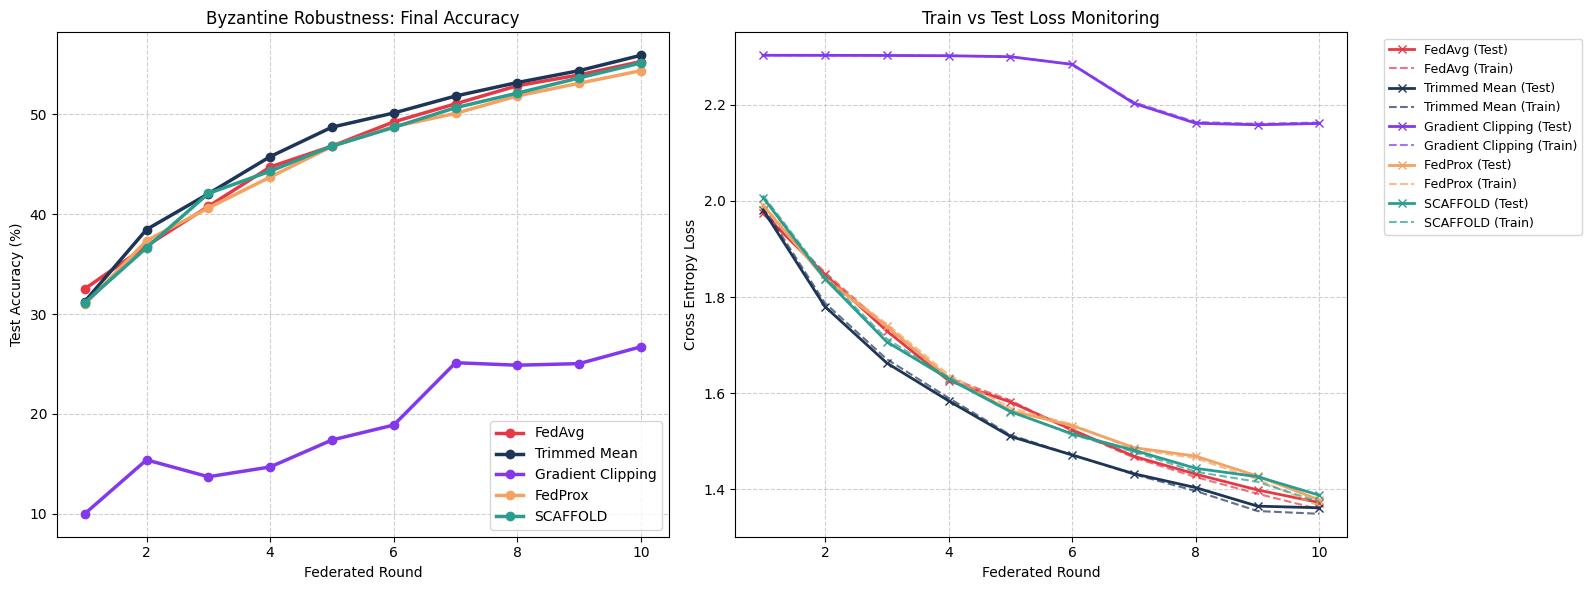

In [15]:
plt.figure(figsize=(16, 6))
colors = {
    'FedAvg': '#E63946',             # Red
    'Trimmed Mean': '#1D3557',       # Dark Blue
    'Gradient Clipping': '#8338EC',  # Purple
    'FedProx': '#F4A261',            # Orange
    'SCAFFOLD': '#2A9D8F'            # Green
}

# --- Subplot 1: Test Accuracy ---
plt.subplot(1, 2, 1)
for strategy in strategies:
    plt.plot(range(1, federated_rounds + 1), history[strategy]['test_acc'],
             marker='o', color=colors[strategy], linewidth=2.5, label=strategy)
plt.title('Byzantine Robustness: Final Accuracy')
plt.xlabel('Federated Round')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)

# --- Subplot 2: Train vs Test Loss ---
plt.subplot(1, 2, 2)
for strategy in strategies:
    c = colors[strategy]

    # Plot Test Loss (Solid, bright line with markers)
    plt.plot(range(1, federated_rounds + 1), history[strategy]['test_loss'],
             marker='x', linestyle='-', linewidth=2, color=c,
             label=f"{strategy} (Test)")

    # Plot Train Loss (Dashed, slightly transparent line)
    plt.plot(range(1, federated_rounds + 1), history[strategy]['train_loss'],
             linestyle='--', linewidth=1.5, color=c, alpha=0.7,
             label=f"{strategy} (Train)")

plt.title('Train vs Test Loss Monitoring')
plt.xlabel('Federated Round')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# Move legend completely outside the plot so nothing is hidden
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

## Empirical Conclusion: Byzantine Robustness & The Honest Majority

The results of the 20% Label Flipping attack yield critical insights into how different aggregation architectures handle malicious actors.

**1. The Resilience of the Honest Majority**
Surprisingly, the vulnerable baseline (FedAvg) achieved 55.29% accuracy, demonstrating that when 80% of the network is honest, a standard mathematical average can physically overpower the corrupted gradients of a malicious minority. The 20% poisoned data acted as resistance, but failed to induce catastrophic forgetting.

**2. The Efficacy of Quantile Filtering**
Trimmed Mean achieved the highest overall accuracy (55.92%). By mathematically discarding the top and bottom 10% of parameter updates, it successfully isolated and dropped the extreme vectors submitted by the compromised clients. This proves that quantile filtering is the mathematically correct defense for Byzantine data poisoning.

**3. The Failure of Absolute Magnitude Limits**
Gradient Clipping (using absolute weight limits rather than difference limits) experienced total model collapse (26.73%). By penalizing the absolute magnitude of the weights, the server continuously erased the network's accumulated intelligence, preventing the honest clients from making historical progress.

**4. The Irrelevance of Drift Correction for Poisoning**
FedProx (54.38%) and SCAFFOLD (55.15%) performed identically to the FedAvg baseline. Because these algorithms are designed to correct *statistical heterogeneity* (Non-IID data) rather than *adversarial malice*, they simply anchored the honest clients and the malicious clients equally, failing to filter out the targeted poison.